# Naive Bayes Classification from Scratch

## Objectives
- Understand the intuition behind Naive Bayes.
- Implement Gaussian Naive Bayes using NumPy.
- Evaluate the classifier using standard metrics.
- Compare the implementation with Scikit-Learn.

## Mathematical Intuition

Naive Bayes applies Bayes' theorem:

P(C|X) ∝ P(X|C)P(C)

For Gaussian Naive Bayes, each feature is assumed to follow a normal distribution
within each class.

The "naive" assumption means features are treated as conditionally independent
given the class.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.naive_bayes import GaussianNB

In [2]:
X, y = make_classification(
    n_samples=400,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    class_sep=1.5,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2", "Feature_3", "Feature_4"]
)

df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,-2.311100,1.867144,-0.355312,-2.754858,1
1,-2.456838,2.587094,-1.846987,-1.520539,1
2,1.895780,-1.683448,1.616091,1.171907,1
3,0.534700,-1.993633,1.494700,0.414907,1
4,-2.718802,1.471871,0.081909,-4.195373,1


In [3]:
class GaussianNaiveBayesScratch:
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}

        for cls in self.classes:
            X_cls = X[y == cls]

            self.mean[cls] = X_cls.mean(axis=0)
            self.var[cls] = X_cls.var(axis=0) + 1e-9
            self.prior[cls] = len(X_cls) / len(X)

        return self

    def _log_gaussian_probability(self, cls, x):
        mean = self.mean[cls]
        var = self.var[cls]

        return -0.5 * np.sum(
            np.log(2 * np.pi * var) +
            ((x - mean) ** 2) / var
        )

    def _predict_single(self, x):
        scores = []

        for cls in self.classes:
            log_prior = np.log(self.prior[cls])
            log_likelihood = self._log_gaussian_probability(cls, x)

            scores.append(log_prior + log_likelihood)

        return self.classes[np.argmax(scores)]

    def predict(self, X):
        return np.array([
            self._predict_single(x)
            for x in np.asarray(X)
        ])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 320
Testing samples: 80


In [7]:
nb = GaussianNaiveBayesScratch()

nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("Actual values:", y_test[:10])

First 10 predictions: [0 0 1 0 0 0 0 0 0 1]
Actual values: [0 1 1 0 0 0 0 0 0 1]


In [8]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ]
})

results

,Metric,Score
0,Accuracy,0.687500
1,Precision,0.894737
2,Recall,0.425000
3,F1-Score,0.576271


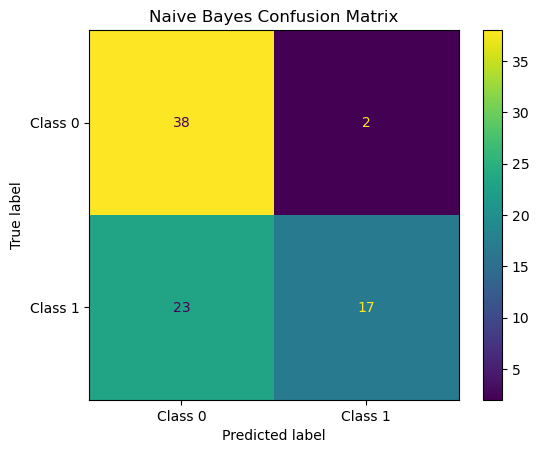

In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [10]:
sklearn_nb = GaussianNB()

sklearn_nb.fit(X_train, y_train)

sklearn_pred = sklearn_nb.predict(X_test)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "From Scratch": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ],
    "Scikit-Learn": [
        accuracy_score(y_test, sklearn_pred),
        precision_score(y_test, sklearn_pred, zero_division=0),
        recall_score(y_test, sklearn_pred, zero_division=0),
        f1_score(y_test, sklearn_pred, zero_division=0)
    ]
})

comparison

,Metric,From Scratch,Scikit-Learn
0,Accuracy,0.687500,0.687500
1,Precision,0.894737,0.894737
2,Recall,0.425000,0.425000
3,F1-Score,0.576271,0.576271
